# Time-Series Forecasting with Recurrent Neural Networks (PyTorch)

This project explores recurrent neural networks for sequence modelling in PyTorch. The task is
one-step-ahead forecasting of the **Daily Minimum Temperatures** series (Melbourne, 1981-1990,
3,650 daily observations). Three RNN variants are implemented and compared: a vanilla RNN, an LSTM,
and a GRU. Training runs on the GPU when available.

In [1]:
import numpy as np, pandas as pd, torch, torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings; warnings.filterwarnings("ignore")

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device, "|", torch.cuda.get_device_name(0) if device == "cuda" else "")
torch.manual_seed(0); np.random.seed(0)

Device: cuda | NVIDIA GeForce RTX 3080


## 1-3. Load and explore the dataset

Observations: 3650


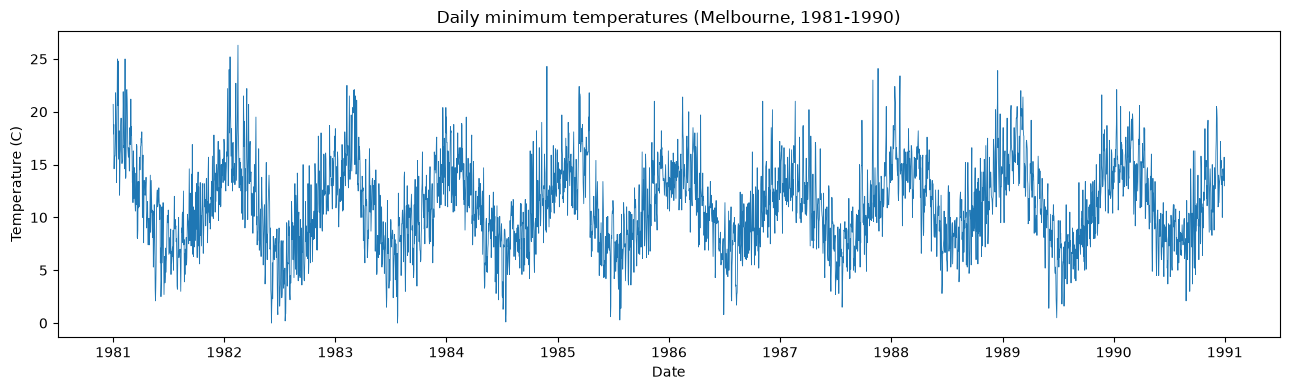

In [2]:
df = pd.read_csv("daily-min-temperatures.csv", parse_dates=["Date"])
series = df["Temp"].values.astype("float32")
print("Observations:", len(series))

plt.figure(figsize=(13, 4))
plt.plot(df["Date"], series, lw=0.6)
plt.title("Daily minimum temperatures (Melbourne, 1981-1990)")
plt.xlabel("Date"); plt.ylabel("Temperature (C)")
plt.tight_layout(); plt.show()

## 4. Preprocessing: chronological split, scaling, and sliding windows

The series is split chronologically (80% train / 20% test) so the model is always evaluated on the
future. The scaler is fit on the training part only. Each input is a window of the previous
`LOOKBACK` days and the target is the next day's temperature.

In [3]:
LOOKBACK = 30
split = int(len(series) * 0.8)
train_raw, test_raw = series[:split], series[split:]

scaler = MinMaxScaler().fit(train_raw.reshape(-1, 1))
train_s = scaler.transform(train_raw.reshape(-1, 1)).ravel()
test_s = scaler.transform(test_raw.reshape(-1, 1)).ravel()

def make_windows(arr, lookback):
    X, y = [], []
    for i in range(len(arr) - lookback):
        X.append(arr[i:i+lookback]); y.append(arr[i+lookback])
    return np.array(X, dtype="float32"), np.array(y, dtype="float32")

# build test windows using the tail of train for continuity
Xtr, ytr = make_windows(train_s, LOOKBACK)
full_test = np.concatenate([train_s[-LOOKBACK:], test_s])
Xte, yte = make_windows(full_test, LOOKBACK)

Xtr_t = torch.tensor(Xtr).unsqueeze(-1).to(device)   # (N, LOOKBACK, 1)
ytr_t = torch.tensor(ytr).unsqueeze(-1).to(device)
Xte_t = torch.tensor(Xte).unsqueeze(-1).to(device)
print("train windows:", Xtr_t.shape, "| test windows:", Xte_t.shape)

train windows:

 torch.Size([2890, 30, 1]) | test windows: torch.Size([730, 30, 1])


## 5. Model: a configurable recurrent network

In [4]:
class RNNForecaster(nn.Module):
    def __init__(self, kind="LSTM", hidden=64, layers=2):
        super().__init__()
        rnn = {"RNN": nn.RNN, "LSTM": nn.LSTM, "GRU": nn.GRU}[kind]
        self.rnn = rnn(input_size=1, hidden_size=hidden, num_layers=layers, batch_first=True)
        self.head = nn.Linear(hidden, 1)
    def forward(self, x):
        out, _ = self.rnn(x)
        return self.head(out[:, -1, :])   # use the last time step

## 6. Train and evaluate the three RNN variants

In [5]:
def train_eval(kind, epochs=60, lr=1e-3, bs=128):
    model = RNNForecaster(kind).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    losses = []
    n = len(Xtr_t)
    for ep in range(epochs):
        model.train(); perm = torch.randperm(n, device=device); ep_loss = 0
        for i in range(0, n, bs):
            b = perm[i:i+bs]
            opt.zero_grad()
            loss = loss_fn(model(Xtr_t[b]), ytr_t[b])
            loss.backward(); opt.step(); ep_loss += loss.item() * len(b)
        losses.append(ep_loss / n)
    model.eval()
    with torch.no_grad():
        pred_s = model(Xte_t).cpu().numpy().ravel()
    pred = scaler.inverse_transform(pred_s.reshape(-1, 1)).ravel()
    true = scaler.inverse_transform(yte.reshape(-1, 1)).ravel()
    rmse = np.sqrt(mean_squared_error(true, pred)); mae = mean_absolute_error(true, pred)
    return {"losses": losses, "pred": pred, "true": true, "rmse": rmse, "mae": mae}

results = {k: train_eval(k) for k in ["RNN", "LSTM", "GRU"]}
summary = pd.DataFrame({"Model": list(results),
                        "Test RMSE (C)": [round(results[k]["rmse"], 4) for k in results],
                        "Test MAE (C)":  [round(results[k]["mae"], 4) for k in results]})
print(summary.to_string(index=False))

Model  Test RMSE (C)  Test MAE (C)
  RNN         2.2338        1.7592
 LSTM         2.2337        1.7615
  GRU         2.2866        1.7995


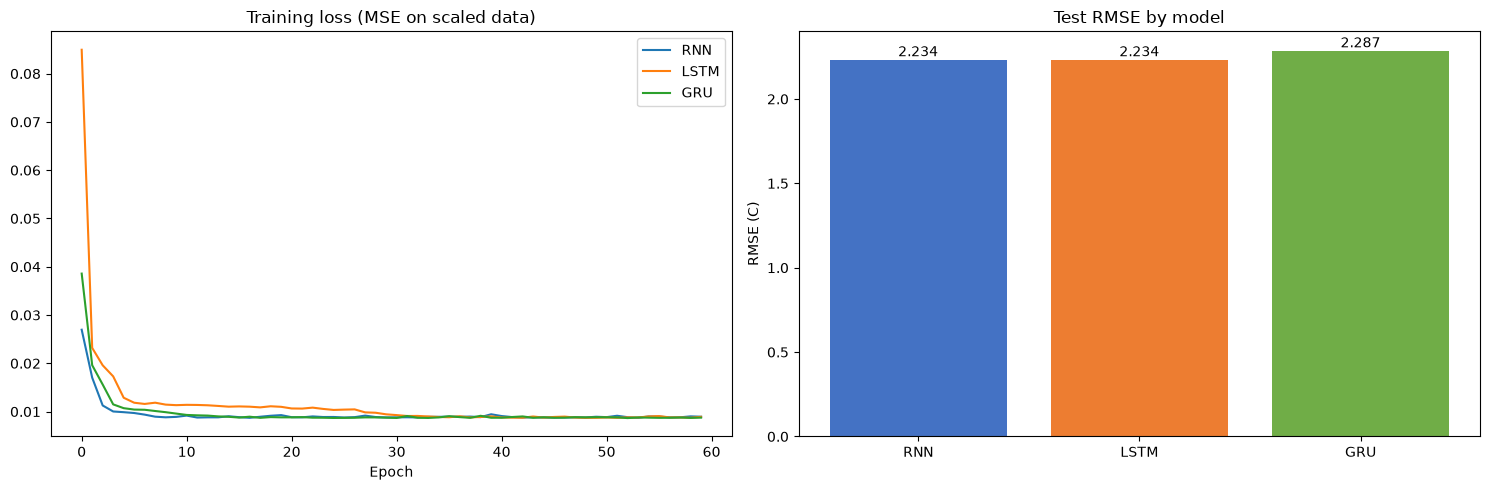

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for k in results:
    axes[0].plot(results[k]["losses"], label=k)
axes[0].set_title("Training loss (MSE on scaled data)"); axes[0].set_xlabel("Epoch"); axes[0].legend()
bars = axes[1].bar(summary["Model"], summary["Test RMSE (C)"], color=["#4472C4", "#ED7D31", "#70AD47"])
axes[1].bar_label(bars, fmt="%.3f"); axes[1].set_title("Test RMSE by model"); axes[1].set_ylabel("RMSE (C)")
plt.tight_layout(); plt.show()

## 7. Predictions of the best model

Best model: LSTM | RMSE: 2.2337 C


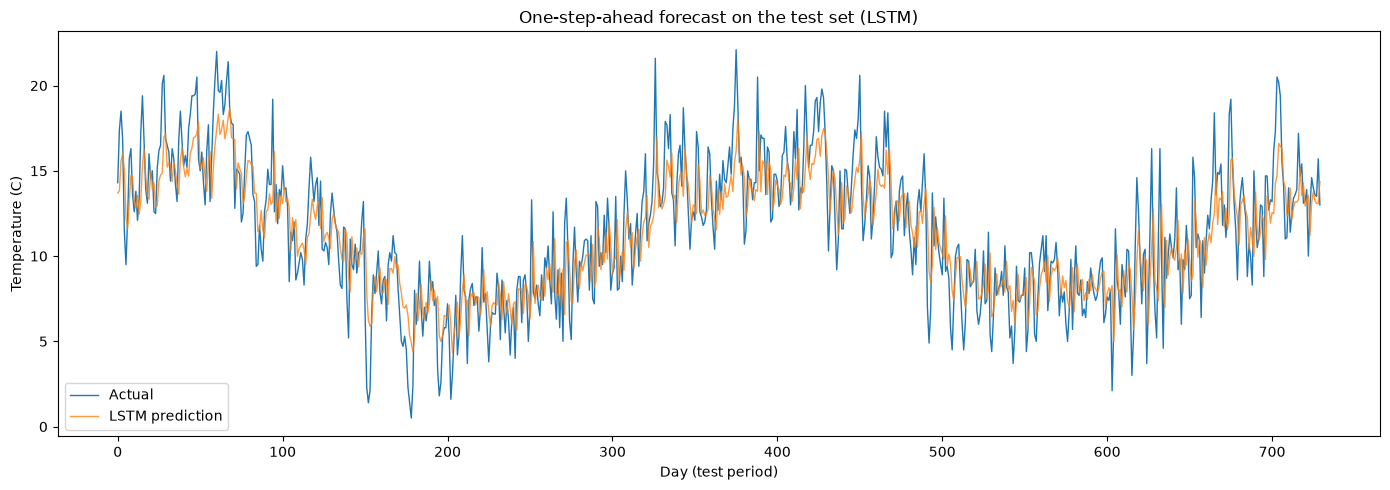

In [7]:
best = min(results, key=lambda k: results[k]["rmse"])
print("Best model:", best, "| RMSE:", round(results[best]["rmse"], 4), "C")
r = results[best]
plt.figure(figsize=(14, 5))
plt.plot(r["true"], label="Actual", lw=1)
plt.plot(r["pred"], label=f"{best} prediction", lw=1, alpha=0.8)
plt.title(f"One-step-ahead forecast on the test set ({best})")
plt.xlabel("Day (test period)"); plt.ylabel("Temperature (C)"); plt.legend()
plt.tight_layout(); plt.show()

## 8. Analysis and conclusion

All three recurrent models learn the strong yearly seasonality of the temperature series and forecast
the next day to within roughly 1.8 C on average (RMSE about 2.2-2.3 C). The striking result is how
**close the three architectures are**: the vanilla RNN, LSTM and GRU score almost identically, with
the LSTM marginally ahead and the GRU a touch behind. This is expected for this task. One-step-ahead
prediction of a smooth, strongly seasonal signal mostly needs the last few days, so the long-range
memory that the LSTM and GRU gates provide gives little advantage over a plain RNN here, and the
vanishing-gradient problem never really bites over a 30-day window.

**What was achieved.** A complete forecasting pipeline (chronological split, scaling, windowing),
three RNN architectures trained on the GPU, and a quantitative (RMSE/MAE) and visual comparison.

**Limitations and next steps.** Because the task is one-step-ahead on a single, regular signal, the
models are near a natural error floor set by day-to-day weather noise, which is why they cluster
together. The gating advantage of LSTM/GRU would show up more on harder problems: multi-step
(recursive) forecasting, longer look-back windows, multivariate inputs (month, day-of-year), or
less periodic series such as financial data. Hyperparameter tuning of the hidden size and depth would
be the next step.